In [1]:
# STEP 1: IMPORT LIBRARIES

import pandas as pd
import numpy as np
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [3]:
# STEP 2: LOAD DATASET

df = pd.read_csv('spam.csv', encoding='latin-1')

df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print("Dataset Preview:")
print(df.head())

Dataset Preview:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


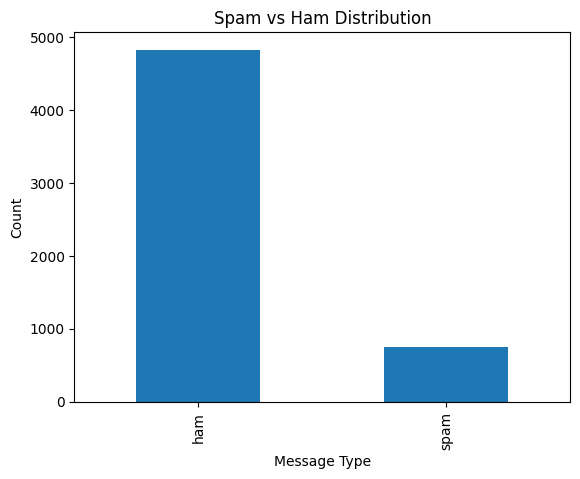

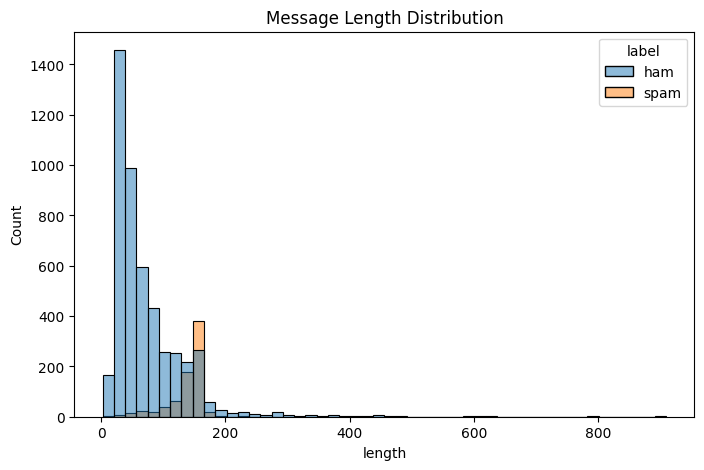

In [4]:
# STEP 3: DATA VISUALIZATION (IMPORTANT)

# Label distribution
df['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Distribution")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

# Message length analysis
df['length'] = df['message'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='length', hue='label', bins=50)
plt.title("Message Length Distribution")
plt.show()

In [5]:
# STEP 4: NLP PREPROCESSING

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = ''.join([c for c in text if c not in string.punctuation])
    words = text.split()

    words = [lemmatizer.lemmatize(stemmer.stem(w))
             for w in words if w not in stop_words]

    return ' '.join(words)

df['cleaned'] = df['message'].apply(preprocess)

# Convert labels
df['label'] = df['label'].map({'ham':0, 'spam':1})

In [7]:
# STEP 5: TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned'], df['label'], test_size=0.2, random_state=42
)

In [8]:
# STEP 6: VECTORIZATION

# TF-IDF
tfidf = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Count Vectorizer
count_vec = CountVectorizer(max_features=3000)
X_train_count = count_vec.fit_transform(X_train)
X_test_count = count_vec.transform(X_test)

In [9]:
# STEP 7: MODEL TRAINING

# Model 1: Naive Bayes (TF-IDF)
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Model 2: Logistic Regression
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=200)

In [10]:
# STEP 8: PREDICTIONS

nb_pred = nb_model.predict(X_test_tfidf)
lr_pred = lr_model.predict(X_test_tfidf)

In [11]:
# STEP 9: EVALUATION

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print("\nNaive Bayes Report:\n", classification_report(y_test, nb_pred))

print("\nLogistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("\nLogistic Regression Report:\n", classification_report(y_test, lr_pred))

Naive Bayes Accuracy: 0.9748878923766816

Naive Bayes Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       965
           1       1.00      0.81      0.90       150

    accuracy                           0.97      1115
   macro avg       0.99      0.91      0.94      1115
weighted avg       0.98      0.97      0.97      1115


Logistic Regression Accuracy: 0.95695067264574

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       0.97      0.70      0.81       150

    accuracy                           0.96      1115
   macro avg       0.96      0.85      0.89      1115
weighted avg       0.96      0.96      0.95      1115



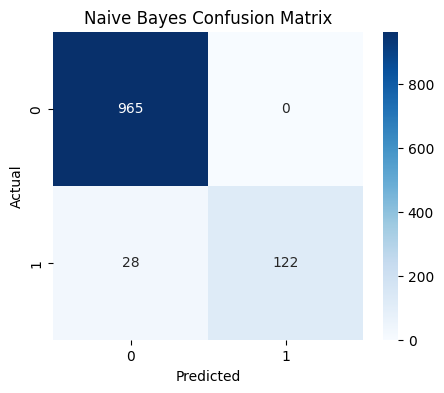

In [12]:
# STEP 10: CONFUSION MATRIX (GRAPH)

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, nb_pred),
            annot=True, fmt='d', cmap='Blues')
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

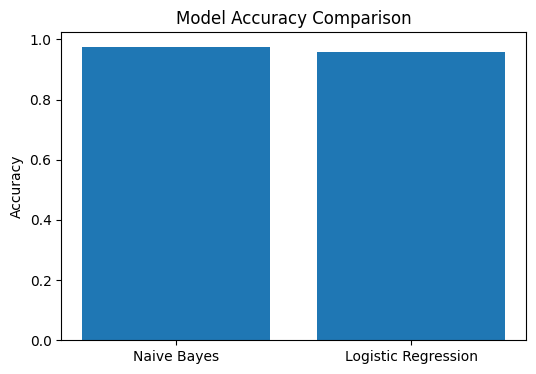

In [13]:
# STEP 11: MODEL COMPARISON GRAPH

nb_acc = accuracy_score(y_test, nb_pred)
lr_acc = accuracy_score(y_test, lr_pred)

models = ['Naive Bayes', 'Logistic Regression']
accuracy = [nb_acc, lr_acc]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [14]:
# STEP 12: SAVE MODEL & VECTORIZER

import pickle

# Save best model (choose one)
pickle.dump(nb_model, open("naive_bayes_model.pkl", "wb"))
pickle.dump(lr_model, open("logistic_model.pkl", "wb"))

# Save vectorizers
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))
pickle.dump(count_vec, open("count_vectorizer.pkl", "wb"))

print("Models and vectorizers saved successfully!")

Models and vectorizers saved successfully!


In [15]:
# Load model
model = pickle.load(open("naive_bayes_model.pkl", "rb"))
vectorizer = pickle.load(open("tfidf_vectorizer.pkl", "rb"))

# Test with new input
sample = ["Congratulations! You won a free prize"]
sample_vec = vectorizer.transform(sample)

prediction = model.predict(sample_vec)

print("Spam" if prediction[0] == 1 else "Ham")

Spam


**https://github.com/kompalwargangotri/nlp-text-classification**